In [1]:
import os
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
%matplotlib inline
#from sklearn.cluster import AgglomerativeClustering
import scipy
import time
import h5py
import ants
import nibabel as nib
from scipy.ndimage import uniform_filter, gaussian_filter
import shutil
from sklearn.cluster import AgglomerativeClustering
from sklearn.feature_extraction.image import grid_to_graph
import gc
import sys
import warnings
from scipy.ndimage import gaussian_filter1d,gaussian_filter
from scipy.signal import butter, sosfiltfilt, filtfilt, freqz,iirnotch
from scipy.ndimage.morphology import binary_erosion
from scipy.ndimage.morphology import binary_dilation
from scipy.ndimage import zoom
from sklearn.mixture import GaussianMixture
import scipy.stats as stats
import sklearn
import pickle
import itertools
import pandas as pd
import nilearn
import brainsss
from mpl_toolkits.mplot3d import Axes3D
from mpl_toolkits.mplot3d.art3d import Poly3DCollection
from scipy.ndimage.morphology import binary_erosion, binary_dilation
from skimage import measure

/home/users/ilanazs/.local/lib/python3.6/site-packages/nilearn/__init__.py:69: FutureWarning:

Python 3.6 support is deprecated and will be removed in release 0.10 of Nilearn. Consider switching to Python 3.8 or 3.9.



In [2]:
### big STA supervox
home_path = '/oak/stanford/groups/trc/data/Ilana/2P/data/later/'
later_dir = '/oak/stanford/groups/trc/data/Ilana/2P/data/later/temp_filter'
cluster_dir = os.path.join(later_dir, 'clustering')
save_dir=os.path.join(later_dir,'figs')
# behaviors = ['inc', 'dec', 'flat']

n_vox=2000

event='best'
event_1='flat'

warnings.filterwarnings("ignore", category=RuntimeWarning)

In [3]:
if event != None:
    event_times_path = os.path.join(home_path, f'{event}_event_times_split_dic.pkl')
else:
    event_times_path = os.path.join(home_path, 'event_times_split_dic.pkl')
with open(event_times_path, 'rb') as file:
    event_times_struct = pickle.load(file)
    f=list(event_times_struct.keys())[0]
    behaviors=list(event_times_struct[f].keys())
    print(f"Found behaviors: {behaviors}")

Found behaviors: ['inc', 'dec', 'flat']


## Load regressed behavior dict

In [4]:
%%time
behave_dict_path=os.path.join(later_dir,f'behave_dict_total_{event}.pkl')
behave_dict_path_1=os.path.join(later_dir,f'behave_dict_total_{event_1}.pkl')
with open(behave_dict_path, 'rb') as file:
    behave_dict_total = pickle.load(file)
    print(behave_dict_total.keys())

with open(behave_dict_path_1, 'rb') as file:
    behave_dict_flat = pickle.load(file)
    print(behave_dict_flat.keys())
    

dict_keys(['inc', 'dec', 'flat'])
dict_keys(['flat'])
CPU times: user 104 ms, sys: 1.17 s, total: 1.27 s
Wall time: 2.08 s


In [5]:
behave_dict_total['flat']=behave_dict_flat['flat']

In [6]:
giant_cluster_labels = np.load(os.path.join(cluster_dir, 'cluster_labels_best_flies.npy'))

In [7]:
giant_cluster_labels.shape

(91, 45844)

In [8]:
supervox_dict_total=brainsss.make_supervox_dict(behave_dict_total, behaviors, n_vox,giant_cluster_labels)

inc shape: (91, 2000, 24)
dec shape: (91, 2000, 24)
flat shape: (91, 2000, 24)


# Put the Supervoxs back into anatomical space

In [9]:
%%time
full_res={}
for behave in behaviors:
    print(behave)
#     supervox_brain=lowpass_dict[behave]
#     supervox_brain=gaussian_filter(supervox_dict_total[behave], sigma=1.5)
    supervox_brain=np.moveaxis(supervox_dict_total[behave],-1,-2)
#     print(np.shape(supervox_brain))
    full_res_brain=brainsss.supervoxel_to_full_res(supervox_brain, giant_cluster_labels, n_vox)
    full_res_brain=np.moveaxis(full_res_brain, 0,-1)
    full_res_brain=np.moveaxis(full_res_brain, 0,-1)
    print(np.shape(full_res_brain))
    full_res[behave]=np.asarray(full_res_brain)

inc
(314, 146, 91, 24)
dec
(314, 146, 91, 24)
flat
(314, 146, 91, 24)
CPU times: user 36.5 s, sys: 1.12 s, total: 37.6 s
Wall time: 37.6 s


In [10]:
fixed = brainsss.load_fda_meanbrain()
# brain=full_res['flat']
# smoothed=gaussian_filter(brain, sigma=1.5)
# masked=np.where(fixed.numpy()[...,None]>0.1, brain, np.nan)
# masked=np.where(fixed.numpy()[...,None]>0.1,brain, np.nan)

In [11]:
atlas = brainsss.load_roi_atlas()
explosion_rois = brainsss.load_explosion_groups()
all_rois = brainsss.unnest_roi_groups(explosion_rois)
roi_masks = brainsss.make_single_roi_masks(all_rois, atlas)
roi_contours = brainsss.make_single_roi_contours(roi_masks, atlas)

In [12]:
def moving_average_2d(arr):
    num_bins=np.shape(arr)[-1]
    window_size=int(num_bins/5)
    # Apply uniform filter to compute the moving average
    return uniform_filter(arr, size=window_size, mode='constant')

def sort_rows_by_max_index(arr):
#     smoothed_row=moving_average_2d(arr)
    max_stim=[]
    max_not_stim=[]
    for i,row in enumerate(arr):
        loc=np.where(row==np.nanmax(row))[0][0]
    #     print(loc)
        if loc>6:
            max_stim.append(arr[i])
        else:
            max_not_stim.append(arr[i])
    max_stim=np.asarray(max_stim)
    max_not_stim=np.asarray(max_not_stim)

    max_indices_stim = np.nanargmax(max_stim, axis=1)
    sorted_order_stim = np.argsort(max_indices_stim)
    sorted_arr_stim = max_stim[sorted_order_stim,:]

    if max_not_stim.size>0:
        sorted_arr=np.vstack([sorted_arr_stim,max_not_stim])
    else:
        sorted_arr=np.vstack(sorted_arr_stim)

    return sorted_arr

In [13]:
%%time

total_vox_sorted={}
for behavior in full_res:
    STA=full_res[behavior]
    total_vox_sorted[behavior]={}
    for area in explosion_rois:
        for key in explosion_rois[area]['rois']:
            area_name=explosion_rois[area]['rois'][key]
            if '_R' in area_name or '_L' in area_name:
                total_area_name=area_name.split('_')
                if len(total_area_name)==3:
                    area_name=total_area_name[0]+'_'+total_area_name[1]
                else:
                    area_name=total_area_name[0]
            roi=key
            roi_mask=roi_masks[roi]
    #             print(np.shape(STA))
            masked_roi=[STA[...,i][roi_mask] for i in range(np.shape(STA)[-1])]
            masked_roi=np.transpose(masked_roi)
    #         roi_sort=sort_rows_by_max_index(masked_roi)
            try:
                np.append(total_vox_sorted[behavior][area_name], masked_roi)
            except KeyError:
                total_vox_sorted[behavior][area_name]=masked_roi

CPU times: user 6.23 s, sys: 259 ms, total: 6.49 s
Wall time: 6.49 s


In [14]:
np.shape(total_vox_sorted[behavior]['FB'])

(12480, 24)

In [15]:
roi_atlas = brainsss.load_roi_atlas()

In [16]:
def extract_roi_signal_traces(roi_ids, roi_masks, warps, hemi, signal_type):
    t0 = time.time()
    roi_time_avgs = []
    for roi in roi_ids[hemi]:
        mask = roi_masks[roi]
        masked_data = warps[:,:,:,:]*mask[np.newaxis,:,:,:] #note z-flip
        if signal_type == 'max':
            roi_time_avg = np.max(masked_data,axis=(1,2,3))
        elif signal_type == 'mean':
            roi_time_avg = np.mean(masked_data,axis=(1,2,3))
        roi_time_avgs.append(roi_time_avg)
    print(time.time()-t0)
    return np.asarray(roi_time_avgs)

In [17]:
color_map_color_1=np.asarray(['#780000','#C1121F','#E0898F','#F0C4C7','#FFFFFF','#D9E6EF','#B3CDDE','#669BBC', '#003049'])[::-1]
cmap_personal = matplotlib.colors.LinearSegmentedColormap.from_list(
    'cmap', color_map_color_1)

top_color=np.asarray(['#780000','#C1121F','#E0898F','#F0C4C7'])[::-1]
bottom=np.asarray(['#D9E6EF','#B3CDDE','#669BBC', '#003049'])[::-1]
top_half_spect = matplotlib.colors.LinearSegmentedColormap.from_list(
    'top_half_spect', top_color)
bottom_half_spect = matplotlib.colors.LinearSegmentedColormap.from_list(
    'bottom_half_spect', bottom)

# Register the new colormap
plt.register_cmap(cmap=top_half_spect)
plt.register_cmap(cmap=bottom_half_spect)

In [18]:
be='inc'
t=2
brain=np.moveaxis(full_res[be],-1,0)
# brain=full_res[be]
input_canvas = np.ones((500,500,3)) #+.5 #.5 for diverging
data_to_plot = brain[t][:,:,::-1]
vmax = 0.1 #this was 0.5 for STA <------------
explosion_map = brainsss.place_roi_groups_on_canvas(explosion_rois,
                                                    roi_masks,
                                                    roi_contours,
                                                    data_to_plot,
                                                    input_canvas,
                                                    vmax=vmax,
                                                    cmap=cmap_personal, diverging=True)#'hot')

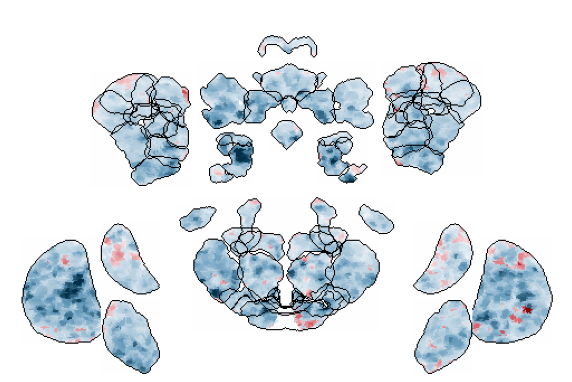

In [19]:
save_dir=os.path.join(later_dir,'figs')
plt.subplots(figsize=(10,10));
# plt.imshow(explosions[40][170:,:]) #this was made with cmap=hot
plt.imshow(explosion_map[170:,:]);
plt.axis('off');
# plt.savefig(os.path.join(save_dir,f'explode_{t}_{be}.png'), dpi=300, bbox_inches='tight')
# plt.savefig(os.path.join(save_dir,f'explode_{t}_{be}_{event}.png'), dpi=300, bbox_inches='tight')

In [20]:
atlas.shape

(314, 146, 91)

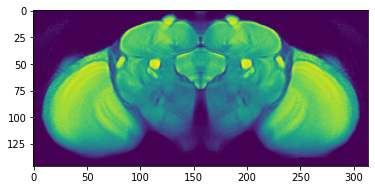

In [21]:
plt.imshow(fixed.numpy()[...,40].T)

In [22]:
verts, faces, _, _ = measure.marching_cubes(fixed.numpy(), level=0.5)

In [23]:
faces.shape

(444362, 3)

In [24]:
test_path='/oak/stanford/groups/trc/data/Brezovec/2P_Imaging/20210818_3d_pickles'
test_files=[]
for file in os.listdir(test_path):
    print(file)
    if 'whole' in file:
        test_files.append(file)

verts_rot_r_mid.pickle
verts_20220118_early.pickle
faces_20220118_pc.pickle
turn
verts_20220118_late.pickle
verts_20220118_rot_early.pickle
faces.pickle
faces_20220118_mid.pickle
20230412_superclusters
faces_20220118_rot.pickle
verts_20220118_mid.pickle
verts_20220118.pickle
verts_rot_r_early.pickle
verts_rot_l_early.pickle
faces_rot_l_early.pickle
faces_whole_brain.pickle
faces_rot_r_early.pickle
faces_rot_r_mid.pickle
faces_20220118.pickle
verts_whole_brain.pickle
verts_20220118_rot.pickle
faces_20220118_rot_early.pickle
faces_20220118_early.pickle
faces_20220118_late.pickle
unique_glm
verts.pickle
verts_20220118_pc.pickle


In [25]:
test_faces=os.path.join(test_path, test_files[0])
print(test_faces)
test_verts=os.path.join(test_path, test_files[1])

/oak/stanford/groups/trc/data/Brezovec/2P_Imaging/20210818_3d_pickles/faces_whole_brain.pickle


In [26]:
with open(test_faces, 'rb') as file:
    faces_file = pickle.load(file)
    print(faces_file.shape)
    
with open(test_verts, 'rb') as file:
    verts_file = pickle.load(file)
    print(verts_file.shape)

(80310, 3)
(40123, 3)


In [27]:
bella_dir = "/oak/stanford/groups/trc/data/Brezovec/2P_Imaging/20221109_cluster_pca/"
### lets visualize these high ipsi low contra on brain
file = os.path.join(bella_dir, 'superclusters_more.npy')
superclusters = np.load(file)
print(np.shape(superclusters))
#with 249 there will be clusters 1-250 inclusive (len=250). cluster 140 is background
superclusters_250 = superclusters[:,:,:,249]
# right brain gets +250 to cluster ID so now 500 clusters
superclusters_250[157:,:,:] += 250

(314, 146, 91, 499)


In [28]:
empty = np.zeros(superclusters_250.shape)
for roi in [21,27,243,248]:
    empty[superclusters_250==roi] = 1
    empty[superclusters_250==roi+250] = 1

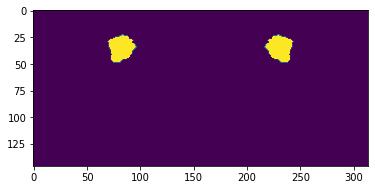

In [29]:
mask_eroded = binary_erosion(empty, structure=np.ones((1,1,1)))
mask_dilated = binary_dilation(mask_eroded, iterations=1)
plt.imshow(np.max(mask_dilated,axis=2).T)

In [30]:
verts_r, faces_r, _, _ = measure.marching_cubes(mask_dilated, level=0.5)

In [31]:
load_file = "/oak/stanford/groups/trc/data/Brezovec/2P_Imaging/anat_templates/20210817_luke_mean_highres.nii"
anat_high_res = np.asarray(nib.load(load_file).get_fdata().squeeze(), dtype='float32')
anat_high_res.shape

(1256, 584, 363)

In [32]:
atlas_path = "/oak/stanford/groups/trc/data/Brezovec/2P_Imaging/anat_templates/jfrc_2018_rois_improve_reorient_transformed_nearest_neighbor.nii"
atlas = np.asarray(nib.load(atlas_path).get_fdata().squeeze(), dtype='float32')
atlas = ants.from_numpy(atlas)
atlas.set_spacing((.76,.76,.76))
#atlas = ants.resample_image(atlas,(2,2,2),use_voxels=False)
atlas = ants.resample_image(atlas,(.5,.5,.5),use_voxels=False)
print(atlas.shape)
atlas = atlas.numpy()
atlas_int = atlas.astype('uint8')

(1256, 584, 363)


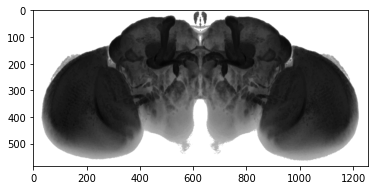

In [33]:
plt.imshow(np.max(anat_high_res, axis=-1).T,cmap='gray_r');

In [34]:
brain=fixed.numpy()
masked=np.where(brain>0.25,brain, False)
empty=np.where(masked==False,masked, True)
full_er=binary_erosion(empty, structure=np.ones((1,1,1)))
full_di=binary_dilation(full_er, iterations=1)
print(np.shape(full_di))

(314, 146, 91)


In [35]:
np.unique(full_di)

array([False,  True])

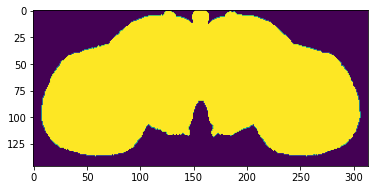

In [36]:
plt.imshow(np.max(full_di,axis=2).T)

In [37]:
verts, faces, _, _ = measure.marching_cubes(full_di, level=0.5)

In [38]:
explosion_rois

{'AOTU_L': {'rois': {79: 'AOTU_L'}, 'x_shift': 80, 'y_shift': 110},
 'AOTU_R': {'rois': {34: 'AOTU_R'}, 'x_shift': -80, 'y_shift': 110},
 'EB': {'rois': {23: 'EB'}, 'x_shift': 0, 'y_shift': 35},
 'FB_group': {'rois': {4: 'NO',
   5: 'BU_R',
   8: 'LAL_R',
   26: 'FB',
   31: 'PVLP_R',
   54: 'BU_L',
   56: 'LAL_L',
   76: 'PVLP_L'},
  'x_shift': 0,
  'y_shift': 0},
 'LO_L': {'rois': {53: 'LO_L'}, 'x_shift': 140, 'y_shift': 215},
 'LO_R': {'rois': {3: 'LO_R'}, 'x_shift': -140, 'y_shift': 215},
 'LP_L': {'rois': {69: 'LP_L'}, 'x_shift': 140, 'y_shift': 145},
 'LP_R': {'rois': {22: 'LP_R'}, 'x_shift': -140, 'y_shift': 145},
 'MED_L': {'rois': {71: 'MED_L'}, 'x_shift': 200, 'y_shift': 175},
 'MED_R': {'rois': {25: 'MED_R'}, 'x_shift': -200, 'y_shift': 175},
 'PB': {'rois': {6: 'PB'}, 'x_shift': 0, 'y_shift': -45},
 'anterior_group': {'rois': {9: 'SAD',
   10: 'CAN_R',
   17: 'MB_PED_R',
   18: 'MB_VL_R',
   19: 'MB_ML_R',
   20: 'FLA_R',
   24: 'AL_R',
   30: 'AVLP_R',
   32: 'IVLP_R',
   

In [39]:
giant_cluster_labels = np.load(os.path.join(cluster_dir, 'cluster_labels_best_flies.npy'))
gcl_anat=giant_cluster_labels.reshape(91,314,146)

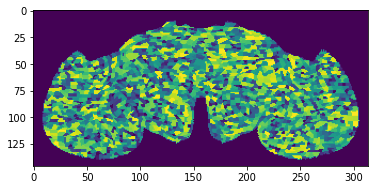

In [40]:
plt.imshow(gcl_anat[50].T)

In [41]:
file_path=os.path.join(cluster_dir, 'model_set_new.pkl')
with open(file_path, 'rb') as file:
    model_set = pickle.load(file)

In [42]:
ids,counts=np.unique(model_set['top_100'], return_counts=True)
top_ids=ids[np.argsort(counts)[::-1]][:100]
top_counts=counts[np.argsort(counts)[::-1]][:100]
top_100=np.asarray(model_set['top_100'])
top_import=np.asarray(model_set['top_import'])
new_importances={}
for i in top_ids:
    new_importances[i]=[]
for i in top_ids:
#     print(i)
    for j,x in enumerate(top_import):
#         print(x)
        importance_vals=x
        val=importance_vals[np.isin(top_100[j,:],i)]
        new_importances[i].append(val)
    new_importances[i]=np.hstack(new_importances[i])

top_importances_final=[]
for ids in new_importances:
    top_importances_final.append(np.mean(new_importances[ids]))
top_importances_final=np.asarray(top_importances_final)

order=np.argsort(top_importances_final)[::-1]
ids=top_ids[order]
count=top_counts[order]
importance=top_importances_final[order]

In [43]:
n_clusters=500
for file in os.listdir(cluster_dir):
#     print(file)
    if f'_{n_clusters}' in file and 'labels' in file and 'total' in file:
        label_files=os.path.join(cluster_dir,file)
giant_total_labels=np.load(label_files)
print(giant_total_labels.shape)

(4171804,)


In [44]:
label_size=np.zeros(500)
for i,label in enumerate(np.sort(np.unique(giant_total_labels))):
    label_size[i]=np.count_nonzero(np.isin(giant_total_labels,label))
max_size_clus=np.where(label_size==np.max(label_size))[0][0]
print(f'the biggest cluster (and therefore the background) is cluster {max_size_clus}')

the biggest cluster (and therefore the background) is cluster 71


In [45]:
for i,label in enumerate(giant_total_labels):
    if label==max_size_clus:
        giant_total_labels[i]=-100
    elif label>max_size_clus:
        giant_total_labels[i]=label-1

In [46]:
giant_labels_anat=giant_total_labels.reshape(314,146,91)
print(giant_labels_anat.shape)

(314, 146, 91)


In [47]:
amt=10
labels_anat_sub_total=np.isin(giant_labels_anat,ids[amt])

In [48]:
# region_mask=roi_masks[24]+roi_masks[70]
# region_mask=roi_masks[49]
# region_mask=gcl_anat[50]
# empty=np.zeros_like(gcl_anat)
# empty=gcl_anat==25
# empty=np.moveaxis(empty,0,-1)
# masked=np.where(fixed.numpy()[...]>0.1,empty, False)
# region_mask=masked
region_mask=labels_anat_sub_total

In [49]:
np.unique(region_mask)

array([False,  True])

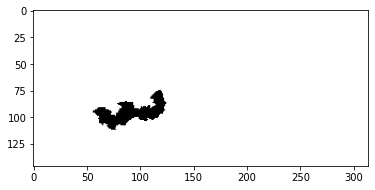

In [50]:
plt.imshow(np.nanmax(region_mask,axis=-1).T,cmap='binary')

In [51]:
%%time
# brain=fixed.numpy()
# masked=np.where(region_mask==True,brain, False)
# empty=np.where(masked==False,masked, True)
full_er_r=binary_erosion(region_mask, structure=np.ones((1,1,1)))
full_di_r=binary_dilation(full_er_r, iterations=1)
print(np.shape(full_di_r))

# full_er_r=binary_erosion(gcl_anat, structure=np.ones((1,1,1)))
# full_di_r=binary_dilation(full_er_r, iterations=1)
# print(np.shape(full_di_r))

(314, 146, 91)
CPU times: user 57.1 ms, sys: 790 µs, total: 57.9 ms
Wall time: 56.6 ms


In [52]:
# %%time
# nx,ny,nz=atlas.shape
# ox,oy,oz=brain.shape
# scale_factors = (nx/ox, ny/oy, nz/oz)
# # Resample using zoom with cubic interpolation (order=3)
# maps_voxel_high_res = zoom(full_di_r, scale_factors, order=3)
# print(np.shape(maps_voxel_high_res))

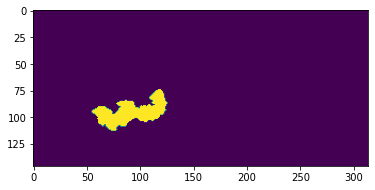

In [53]:
plt.imshow(np.max(full_di_r,axis=2).T)
# plt.imshow(full_di_r[50].T)

In [54]:
verts_region, faces_region, _, _ = measure.marching_cubes(full_di_r, level=0.5)

In [90]:
def visualize_mesh_matplotlib(vertices, faces,roi_vertices=None, roi_faces=None, elev=10, azim=-85, ax=None):
    """
    Visualize mesh using matplotlib
    """
    
    # Create triangular faces for the mesh
    triangles = vertices[faces]
    
    # Create 3D polygon collection
    mesh = Poly3DCollection(triangles, alpha=0.05, facecolor='#F5F5F5', 
                               edgecolor='gray', linewidths=0.2)
    ax.add_collection3d(mesh)
    
    if roi_vertices is not None and roi_faces is not None:
        roi_triangles = roi_vertices[roi_faces]
        roi_mesh = Poly3DCollection(roi_triangles, alpha=0.8, facecolor='#9400D3', 
                                    edgecolor='#493566',linewidths=0.2)
        ax.add_collection3d(roi_mesh)
    
    # Set the aspect ratio and limits
    ax.set_xlim(vertices[:,0].min(), vertices[:,0].max())
    ax.set_ylim(vertices[:,1].min(), vertices[:,1].max())
    ax.set_zlim(vertices[:,2].min(), vertices[:,2].max())
    ax.view_init(elev=elev, azim=azim)
    
#     ax.set_xlabel('X')
#     ax.set_ylabel('Y')
#     ax.set_zlabel('Z')
    ax.axis('off');


In [91]:
# def visualize_mesh_matplotlib(vertices, faces, roi_vertices=None, roi_faces=None, 
#                             elev=10, azim=-85, ax=None, show_slice=True, slice_z=None):
#     """
#     Visualize mesh using matplotlib with slice plane outline
#     """
    
#     # Your existing code...
#     triangles = vertices[faces]
#     mesh = Poly3DCollection(triangles, alpha=0.05, facecolor='#F5F5F5', 
#                                edgecolor='gray', linewidths=0.2)
#     ax.add_collection3d(mesh)
    
#     if roi_vertices is not None and roi_faces is not None:
#         roi_triangles = roi_vertices[roi_faces]
#         roi_mesh = Poly3DCollection(roi_triangles, alpha=0.8, facecolor='#EF476F', 
#                                     edgecolor='#493566',linewidths=0.2)
#         ax.add_collection3d(roi_mesh)
    
#     # Add slice plane outline
#     if show_slice:
#         if slice_z is None:
#             slice_z = (vertices[:,2].min() + vertices[:,2].max()) / 2
        
#         x_min, x_max = vertices[:,0].min(), vertices[:,0].max()
#         y_min, y_max = vertices[:,1].min(), vertices[:,1].max()
        
#         # Draw rectangle outline at slice level
#         slice_x = [x_min, x_max, x_max, x_min, x_min]
#         slice_y = [y_min, y_min, y_max, y_max, y_min]
#         slice_z_line = [slice_z] * 5
        
#         ax.plot(slice_x, slice_y, slice_z_line, 'b-', linewidth=2, label='Mid-plane')
    
#     # Rest of your existing code...
#     ax.set_xlim(vertices[:,0].min(), vertices[:,0].max())
#     ax.set_ylim(vertices[:,1].min(), vertices[:,1].max())
#     ax.set_zlim(vertices[:,2].min(), vertices[:,2].max())
#     ax.view_init(elev=elev, azim=azim)
#     ax.axis('off')

In [92]:
# def visualize_mesh_matplotlib(vertices, faces, roi_vertices=None, roi_faces=None, 
#                             elev=10, azim=-85, ax=None, show_slice=True,slice_z=None):
#     """
#     Add cross-section lines through the middle of the brain
#     """
    
#     # Your existing mesh code...
#     triangles = vertices[faces]
#     mesh = Poly3DCollection(triangles, alpha=0.05, facecolor='#F5F5F5', 
#                                edgecolor='gray', linewidths=0.2)
#     ax.add_collection3d(mesh)
    
#     if roi_vertices is not None and roi_faces is not None:
#         roi_triangles = roi_vertices[roi_faces]
#         roi_mesh = Poly3DCollection(roi_triangles, alpha=0.8, facecolor='#EF476F', 
#                                     edgecolor='#493566',linewidths=0.2)
#         ax.add_collection3d(roi_mesh)
    
#     # Add cross-section lines
#     if show_slice:
#         x_mid = (vertices[:,0].min() + vertices[:,0].max()) / 2
#         y_mid = (vertices[:,1].min() + vertices[:,1].max()) / 2
#         z_mid = (vertices[:,2].min() + vertices[:,2].max()) / 2
        
#         x_min, x_max = vertices[:,0].min(), vertices[:,0].max()
#         y_min, y_max = vertices[:,1].min(), vertices[:,1].max()
#         z_min, z_max = vertices[:,2].min(), vertices[:,2].max()
        
#         # Sagittal line (front to back through middle)
#         ax.plot([x_min, x_max], [y_mid, y_mid], [z_mid, z_mid], 
#                 'k--', linewidth=3, alpha=0.7, label='Sagittal')
        
#         # Coronal line (left to right through middle)
#         ax.plot([x_mid, x_mid], [y_min, y_max], [z_mid, z_mid], 
#                 'k--', linewidth=3, alpha=0.7, label='Coronal')
#         if slice_z is None:
#             slice_z = (vertices[:,2].min() + vertices[:,2].max()) / 2
        
#             x_min, x_max = vertices[:,0].min(), vertices[:,0].max()
#             y_min, y_max = vertices[:,1].min(), vertices[:,1].max()

#             # Draw rectangle outline at slice level
#             slice_x = [x_min, x_max, x_max, x_min, x_min]
#             slice_y = [y_min, y_min, y_max, y_max, y_min]
#             slice_z_line = [slice_z] * 5

#             ax.plot(slice_x, slice_y, slice_z_line, 'k--', linewidth=2, label='Mid-plane')
    
#     # Rest of existing code...
#     ax.set_xlim(vertices[:,0].min(), vertices[:,0].max())
#     ax.set_ylim(vertices[:,1].min(), vertices[:,1].max())
#     ax.set_zlim(vertices[:,2].min(), vertices[:,2].max())
#     ax.view_init(elev=elev, azim=azim)
#     ax.axis('off')

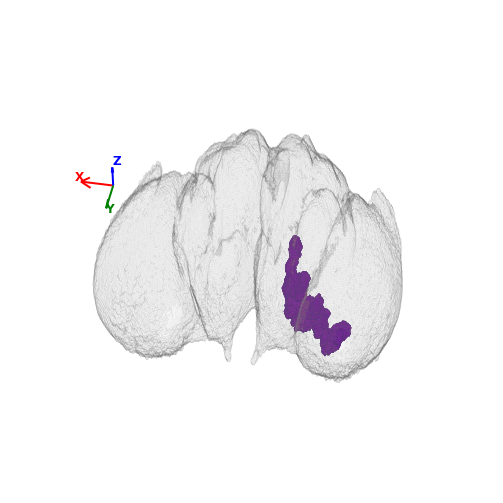

In [93]:
#[40,85] '#F5F5F5'
fig = plt.figure(figsize=(12, 9))
ax = fig.add_subplot(111, projection='3d')
# fig = visualize_mesh_matplotlib(verts_file, faces_file, roi_vertices=verts_r, roi_faces=faces_r, elev=10, azim=-85)
visualize_mesh_matplotlib(verts, faces, roi_vertices=verts_region, roi_faces=faces_region, elev=45, azim=100,ax=ax) #show_slice=True)
# plt.savefig(os.path.join(save_dir,'3D_clust2.png'), dpi=300, bbox_inches='tight', transparent=True)

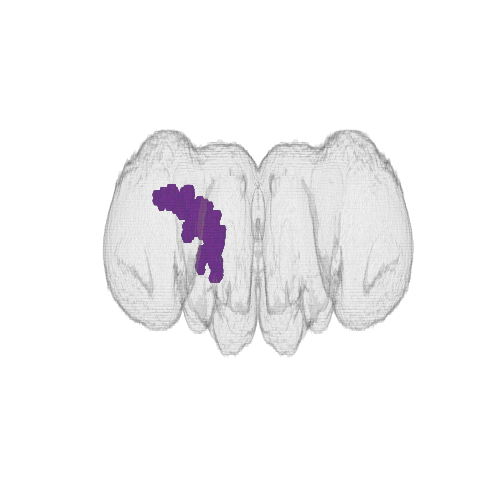

In [59]:
fig = plt.figure(figsize=(12, 9))
ax1 = fig.add_subplot(111, projection='3d')
visualize_mesh_matplotlib(verts, faces, roi_vertices=verts_region, roi_faces=faces_region, elev=180, azim=-90,ax=ax1)
# plt.savefig(os.path.join(save_dir,'MB_VL_3D.png'), dpi=300, bbox_inches='tight', transparent=True)